# 2D non-rigid, center-out — WSe₂

**After affine.** Explicit `correct_affine()`, then the center-out scanline
solve. Saves `data/wse2/drift.zip`.

## Strategy

1. **Affine first** — non-rigid only polishes residual scanline warp.
2. **One knot per scanline** — center-out solves rows one at a time, outward
   from the center of the slow axis.
3. **Judge with `plot_combined` + `report()`**


Static rendering is used here so the figures are visible without running
the notebook. Set `INTERACTIVE = True` in the device cell for linked
widget viewing.

## Environment

Install the reviewed paper API and latest published `quantem.widget` release
candidate. One notebook supports both interactive and static/report output:

```bash
python -m pip install --upgrade \
  "git+https://github.com/bobleesj/quantem.git@drift-paper"
python -m pip install --pre --upgrade \
  --index-url https://test.pypi.org/simple \
  --extra-index-url https://pypi.org/simple quantem.widget
```

## Data

Download the [raw WSe₂ data](https://drive.google.com/drive/folders/16ILwlaFl57VZeb1QS6rTCgaPXv-km63s)
and place the files in `tutorials/imaging/drift/data/wse2/`. The pair is 4096² and is
Fourier-cropped to 1024² below, the resolution the correction is run at.

## Device and paths

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import copy
from pathlib import Path

import matplotlib
import numpy as np
import quantem.widget as qw
from scipy.ndimage import gaussian_filter

from quantem.imaging import DriftCorrection
from quantem.imaging.drift.io import read_emd

# Raw EMDs + AutoSerialized result under DATA.
DATA = Path("data/wse2")
RESULT = DATA / "drift.zip"

SHAPE = 1024

# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = False
VIEW_MODE = "interactive" if INTERACTIVE else "static"

matplotlib.rcParams["figure.dpi"] = 100

qw.profile()

quantem.widget  0.0.1rc37
  install       published package
quantem.gpu     0.0.1rc7
  install       published package
quantem         0.1.9
torch           2.14.0+cu130  device=cuda (NVIDIA RTX PRO 6000)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=3)
  GPU0            1.8 used / 102 GB  (100 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.12.11


## Load

`read_emd` reads scan rotation from Velox metadata — do not hardcode angles.
The pair is read here rather than through `from_emd` because the crop below
happens before the correction is built.

In [2]:
scans = [
    read_emd(DATA
             / "0136-20251124_1927_WSe2_good_STEM_HAADF_14.9_nm_6.70_Mx.emd"),
    read_emd(DATA
             / "0137-20251124_1927_WSe2_good_STEM_HAADF_14.9_nm_6.70_Mx.emd"),
]
angles = [float(s.metadata["scan_rotation_deg"]) for s in scans]

## Preprocess data
sigma=1 Gaussian, FFT center crop, divide by the
per-image max, subtract the mean

In [3]:
raw = np.stack([np.asarray(s.array, dtype=float) for s in scans])
raw = gaussian_filter(raw, (0.0, 1.0, 1.0))

native = raw.shape[1]
half = SHAPE // 2
ft = np.fft.fftshift(np.fft.fft2(raw, axes=(1, 2)), axes=(1, 2))
ft = ft[:, native // 2 - half:native // 2 + half,
        native // 2 - half:native // 2 + half]
raw = np.real(np.fft.ifft2(np.fft.ifftshift(ft, axes=(1, 2)), axes=(1, 2)))
raw = raw * (SHAPE / native) ** 2

raw = raw / raw.max(axis=(1, 2), keepdims=True)
raw = raw - raw.mean(axis=(1, 2), keepdims=True)

## Create drift variable

In [4]:
drift = DriftCorrection.from_images(
    raw[0], raw[1],
    scan_direction_degrees=angles,
)

drift.preprocess(
    padding_fraction=0.25,
    padding_value="median",
    smoothing_sigma=1.0,
    num_knots=1,
    verbose=False,
)

## Affine first (explicit grid)

`lowpass` is the real-space Gaussian sigma in pixels. `ramp` and
`cost_taper` are a separate edge-softening width, also in pixels.

In [5]:
drift.align_translation(
    max_image_shift=256.0,
    lowpass=5.0,
    ramp=32,
    subpixel="parabola",
    show_combined=False,
    show_knots=False,
    verbose=False,
)

In [6]:
drift.correct_affine(
    max_drift_rate=0.075,
    num_rates=11,
    refine=True,
    refine_divisor=10,
    lowpass=5.0,
    cost_taper=32,
    subpixel="parabola",
    chunk_size=8,
    max_image_shift=256.0,
    show_combined=False,
    show_knots=False,
    verbose=False,
)

## Check affine — `plot_combined`

Confirm yellow registration before spending time on non-rigid. If affine is
bad, fix affine — do not "rescue" with non-rigid.

(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: title={'center': 'Combined: raw (RGB)'}>,
        <Axes: title={'center': 'Combined: after affine correction (RGB)'}>],
       dtype=object))

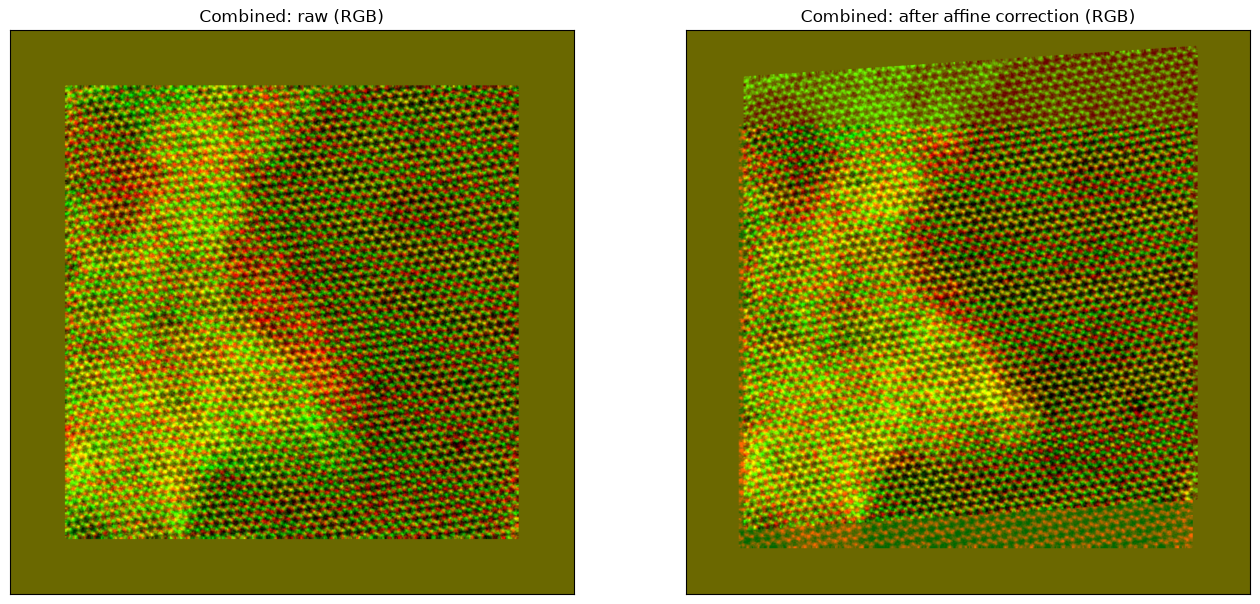

In [7]:
drift.plot_combined(
    stage=("initial", "affine"),  # before | after affine
    interactive=INTERACTIVE,      # linked widget | static Matplotlib
    width=620,                    # panel width px — 400 | 620 | 900
    # show_fft=False,             # FFT under each panel
    # zoom=1.0,
    # center=(0.0, 0.0),          # fractional (row, col) in [-0.5, 0.5]
)

## Non-rigid, torch

The batched Adam solve, on a deep copy of the affine result so that both
non-rigid runs start from the same seed and differ only in solver. These are
figure 3's settings; no `lowpass`, which the fork defaults off.

In [8]:
torch_drift = copy.deepcopy(drift)
torch_drift.correct_nonrigid(
    optimizer="adam",
    num_refine_cycles=128,
    optimizer_steps=50,
    learning_rate=0.02,
    knot_smoothing_sigma=16.0,
    trend_order=1,
    update_fraction=0.8,
    max_image_shift=32.0,
    show_combined=False,
    show_scans=False,
    show_knots=False,
    show_knot_plot=False,
    show_report=False,
    verbose=True,
)

Solving nonrigid drift (adam):   0%|          | 0/128 [00:00<?, ?it/s]

Solving nonrigid drift (adam):   0%|          | 0/128 [00:00<?, ?it/s, error=0.009565, best=0.009565]

Solving nonrigid drift (adam):   1%|          | 1/128 [00:00<01:56,  1.09it/s, error=0.009565, best=0.009565]

Solving nonrigid drift (adam):   1%|          | 1/128 [00:00<01:56,  1.09it/s, error=0.009313, best=0.009313]

Solving nonrigid drift (adam):   1%|          | 1/128 [00:00<01:56,  1.09it/s, error=0.009047, best=0.009047]

...

Solving nonrigid drift (adam):  20%|█▉        | 25/128 [00:01<00:03, 31.59it/s, error=0.007095, best=0.007095]

Solving nonrigid drift (adam):  20%|█▉        | 25/128 [00:01<00:03, 31.59it/s, error=0.007096, best=0.007095]

Solving nonrigid drift (adam):  20%|█▉        | 25/128 [00:01<00:03, 31.59it/s, error=0.007098, best=0.007095]

Solving nonrigid drift (adam):  20%|█▉        | 25/128 [00:01<00:03, 31.59it/s, converged at cycle 31, error=0.007098, best=0.007095]

Solving nonrigid drift (adam):  23%|██▎       | 30/128 [00:01<00:04, 20.63it/s, converged at cycle 31, error=0.007098, best=0.007095]

## Check the torch solve — `plot_combined`

(<Figure size 2400x800 with 3 Axes>,
 array([<Axes: title={'center': 'Combined: raw (RGB)'}>,
        <Axes: title={'center': 'Combined: after affine correction (RGB)'}>,
        <Axes: title={'center': 'Combined: after non-rigid correction (RGB)'}>],
       dtype=object))

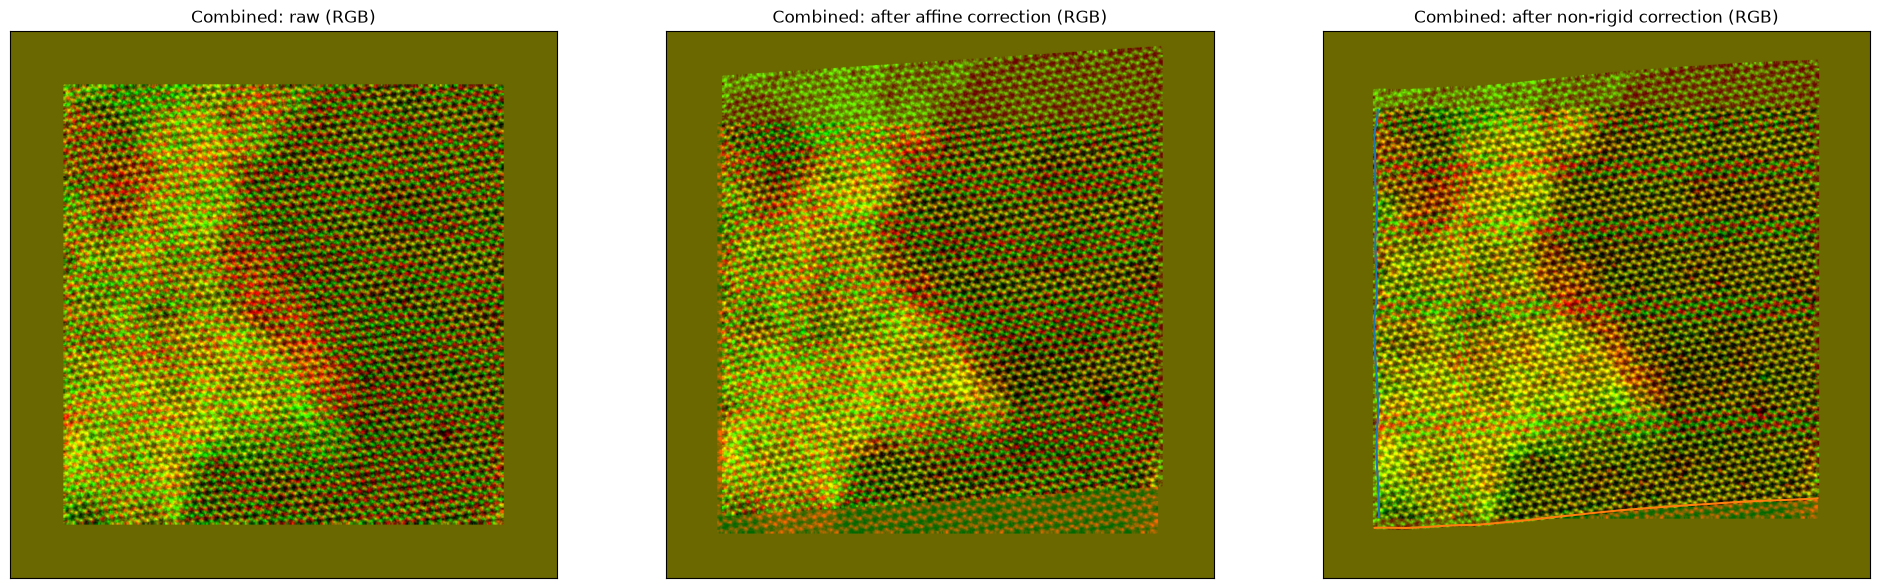

In [9]:
torch_drift.plot_combined(
    stage=("initial", "affine", "nonrigid"),
    interactive=INTERACTIVE,      # linked widget | static Matplotlib
    width=620,
    # show_fft=False,
    # zoom=1.0,
    # center=(0.0, 0.0),
)

## Center-out non-rigid

Rows are solved one at a time, outward from the center of the slow axis, each
seeded from the neighbor one row closer to the center. Fixing the center row
fixes the gauge, which is where most of the uncontrolled error in an
unanchored per-row solve lives.

### Why these publication settings?

`step_cap_px` boxes each row around its prediction, and `relaxation` pulls the
accepted solution back toward that prediction — together they are what keep a
row from jumping a lattice repeat. `update_fraction` is off because
`relaxation` already under-relaxes.

`lowpass` reaches only the per-sweep translation solve; the reference image
the row solver sees is unsoftened.

No `align_translation` afterwards: each sweep already ends with one.

In [10]:
drift.correct_nonrigid_center_out(
    num_sweeps=8,
    max_optimize_iterations=4,
    step_cap_px=8.0,
    increment_alpha=0.4,
    step_alpha=0.1,
    step_clip_px=0.1,
    relaxation=0.25,
    knot_smoothing_sigma=16.0,
    knot_smoothing_poly_order=1,
    update_fraction=None,
    max_image_shift=256,
    lowpass=5.0,
    cost_taper=32,
    subpixel="parabola",
    show_combined=False,
    show_knots=False,
    verbose=True,
)

Solving nonrigid drift (center-out):   0%|          | 0/8 [00:00<?, ?it/s]

## Check non-rigid — `plot_combined`

Three stages side by side. Look for yellow tighten vs affine **without**
lattice hop or zipper. Then read scores.

(<Figure size 2400x800 with 3 Axes>,
 array([<Axes: title={'center': 'Combined: raw (RGB)'}>,
        <Axes: title={'center': 'Combined: after affine correction (RGB)'}>,
        <Axes: title={'center': 'Combined: after non-rigid correction (RGB)'}>],
       dtype=object))

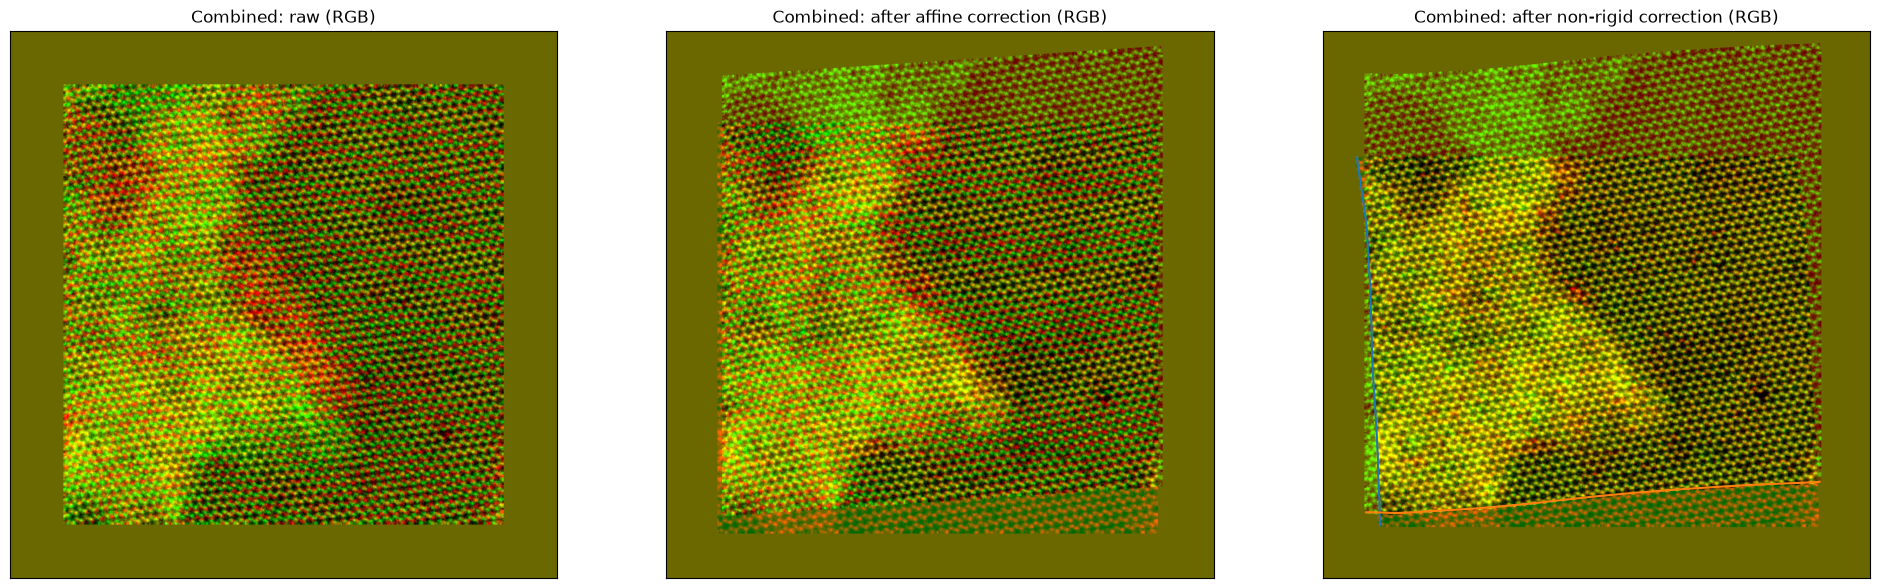

In [11]:
drift.plot_combined(
    stage=("initial", "affine", "nonrigid"),
    interactive=INTERACTIVE,      # linked widget | static Matplotlib
    width=620,
    # show_fft=False,
    # zoom=1.0,
    # center=(0.0, 0.0),
)

## Scores — `report()`

Regional NCC on the common-coverage mask across stages. Non-rigid should not
hurt affine regional scores on a good run.

In [12]:
drift.report()

,Common NCC,Top third,Middle third,Bottom third,Coverage
Mutual stage,,,,,
before,0.186489,0.135308,0.158027,0.246986,0.764219
affine,0.284552,0.247906,0.265498,0.321163,0.764219
nonrigid,0.851261,0.840759,0.849904,0.858658,0.764219


## Corrected result — `show()`

Grayscale product gallery (not the RGB registration check). Display-only
knobs.

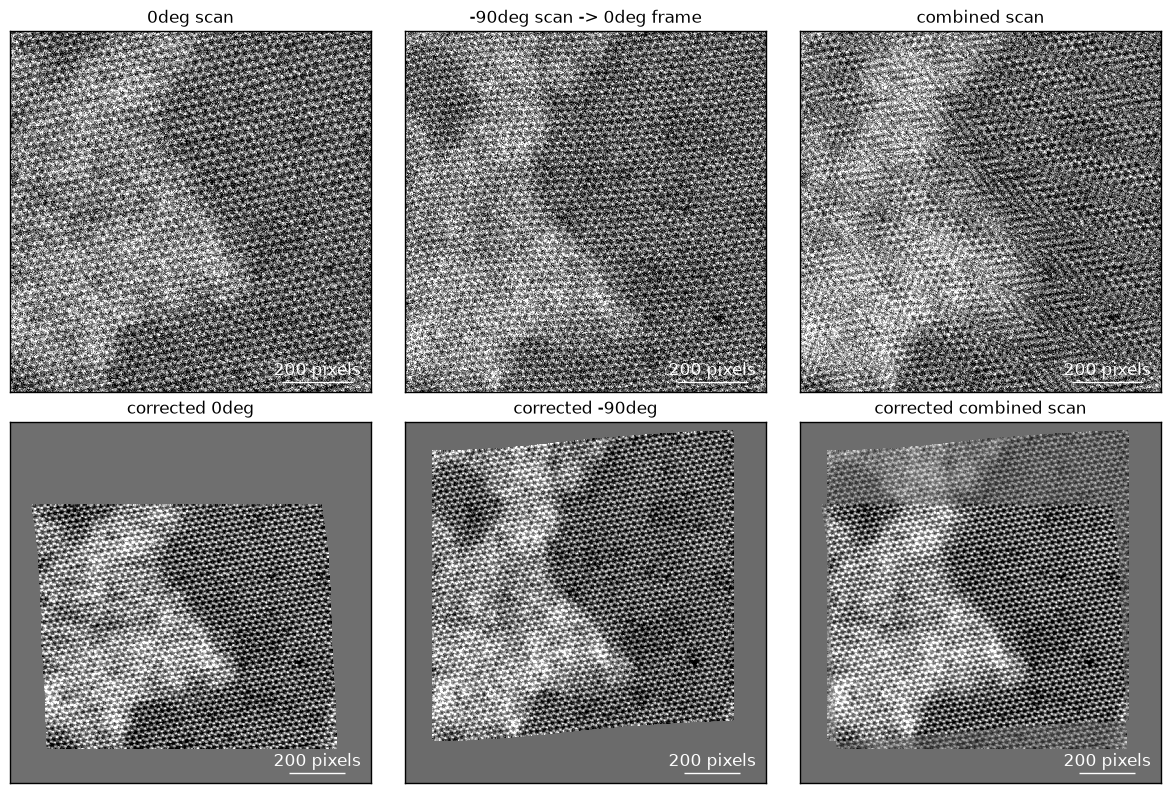

In [13]:
drift.show(
    mode=VIEW_MODE,
    cmap="gray",           # gray | inferno | viridis | plasma
    auto_contrast=True,    # percentile clim | full range
    link_contrast=True,    # shared clim across panels
    smooth=False,          # nearest | interpolated
    show_fft=False,        # FFT companion panels
    # zoom=1.0,
    # size=400,
    # center=(0.0, 0.0),
)

## Save

AutoSerialize next to the EMDs.

In [14]:
DATA.mkdir(parents=True, exist_ok=True)
drift.save(RESULT, mode="o")
print(f"Saved: {RESULT}")

Saved: data/wse2/drift.zip
